### SVM Kernels Indepth Intuition And Practical Explanation
* To classify non-linear data by transforming it into a higher-dimensional space where it becomes easier to separate.
* To create flexible decision boundaries (curved instead of straight lines) when a linear kernel cannot separate the classes.
* To improve classification accuracy on complex datasets without manually creating new features.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# creating the coordinates of a circle
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [3]:
# it creates a smaller circle.
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

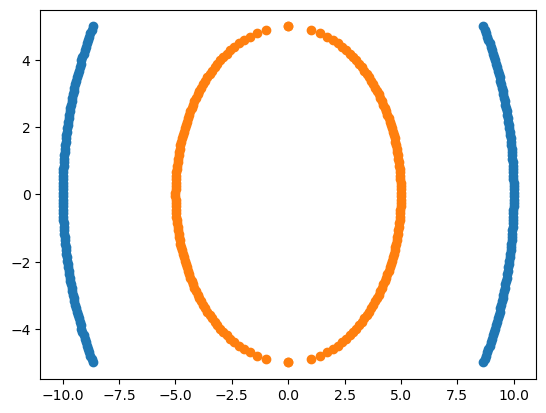

In [4]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [12]:
# creates the final dataset that will be used to train a Machine Learning model
import pandas as pd

#Create the First Dataset (Outer Circle)
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0 #assign label to outer circle as 0 

# Create the Second Dataset (Inner Circle)
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1 #assign label to inner circle as 1

# Combine Both Datasets
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [13]:
#independent and dependent feature
X=df.iloc[:,:2]
y=df.Y

In [26]:
# split dataset using train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# We perform a train-test split to train the model on one part of the data and
# evaluate its performance on unseen data to check how well it generalizes.

In [27]:
y_train

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

In [39]:
# Create and train the SVM Model linear 
from sklearn.svm import SVC
classifier=SVC(kernel="linear") #draw best fit line 
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
# Imports the accuracy_score function, which is used to measure how accurately the model makes predictions.
from sklearn.metrics import accuracy_score
y_pred=classifier.predict(X_test) #Uses the trained SVM model to predict the class labels for the test data
accuracy_score(y_test,y_pred) #Compares the actual labels (y_test) with the predicted labels (y_pred).

0.45

accuracy on linear for this data is very very low bcz we cannot separate it using linear line

#### RBF Kernel
 The purpose of the RBF(Radial Basis Function) kernel is to help SVM classify complex non-linear data by creating a flexible decision boundary. 

In [44]:
from sklearn.svm import SVC
classifier=SVC(kernel="rbf") #perform RBF Kernel 
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
# Imports the accuracy_score function, which is used to measure how accurately the model makes predictions.
from sklearn.metrics import accuracy_score
y_pred=classifier.predict(X_test) #Uses the trained SVM model to predict the class labels for the test data
accuracy_score(y_test,y_pred) #Compares the actual labels (y_test) with the predicted labels (y_pred).

1.0

#### Polynomial Kernel
A Polynomial Kernel is used when the data cannot be separated by a straight line.

In [48]:
from sklearn.svm import SVC
classifier=SVC(kernel="poly") #perform polynomial Kernel 
classifier.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
# Imports the accuracy_score function, which is used to measure how accurately the model makes predictions.
from sklearn.metrics import accuracy_score
y_pred=classifier.predict(X_test) #Uses the trained SVM model to predict the class labels for the test data
accuracy_score(y_test,y_pred) #Compares the actual labels (y_test) with the predicted labels (y_pred).

0.59

#### TO Use a Linear Kernel on non-linear data, you first need to transform the data into a space where it becomes linearly separable.
Polynomial Feature Transformation (Most Common)

A Linear SVM can only draw a straight hyperplane. By adding polynomial features (X1², X2², and X1×X2), we transform the data into a higher-dimensional feature space where it may become linearly separable. This lets a Linear SVM solve problems that originally had non-linear decision boundaries.

In [50]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [51]:
### Independent and Dependent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [52]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.25, random_state = 0)

In [53]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


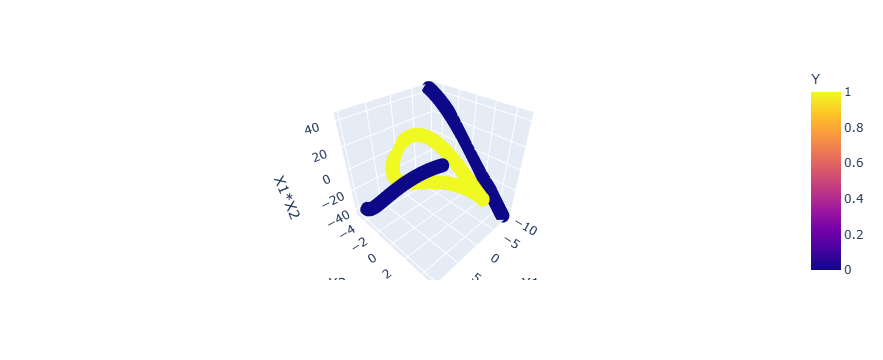

In [54]:
# Imports Plotly Express, a library used to create interactive graphs.
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
              color='Y') # 3D graph one color with calss 0 and other color with class 1
fig.show()

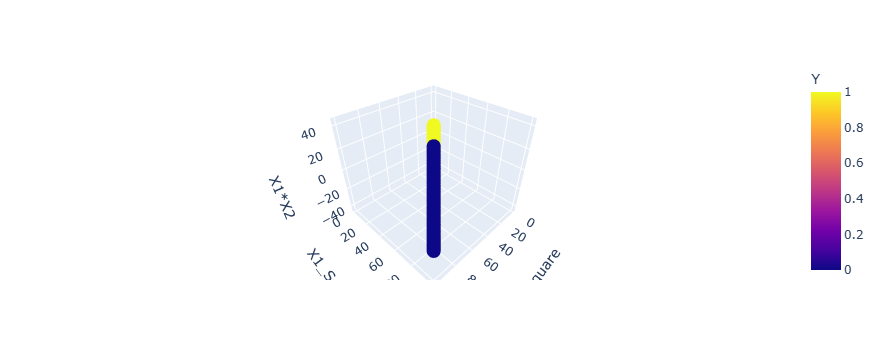

In [58]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',
              color='Y')
fig.show()

In [63]:
# now perform linear kernel 
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)
# accuracy is 1 thats good 

1.0